In [17]:
import os
import sys
print(os.getcwd())
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt


/home/hice1/snachimuthu7/BMED6780/VisualTracking/scripts/playground


In [18]:
!ls ../../autoROI_imgs/cropped

S_0    S_104  S_11   S_115  S_122  S_129  S_134  S_14	S_145  S_151
S_1    S_105  S_110  S_116  S_123  S_13   S_135  S_140	S_146  S_152
S_10   S_106  S_111  S_117  S_124  S_130  S_136  S_141	S_147  S_153
S_101  S_107  S_112  S_118  S_125  S_131  S_137  S_142	S_148  S_154
S_102  S_108  S_113  S_119  S_126  S_132  S_138  S_143	S_149  S_155
S_103  S_109  S_114  S_12   S_128  S_133  S_139  S_144	S_15   S_156


In [31]:
!ls ../../../../../../../../storage/ice1/shared/bmed6780/mip_group_4/'openEDS Dataset'/openEDS/openEDS/train/

images	labels	masks


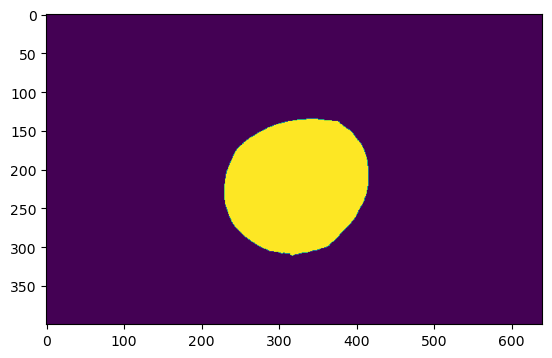

In [27]:
test_mask = Image.open(
    "../../../../../../../../storage/ice1/shared/bmed6780/mip_group_4/"
    "openEDS Dataset/openEDS/openEDS/train/masks/004645.png"
)
plt.imshow(test_mask)

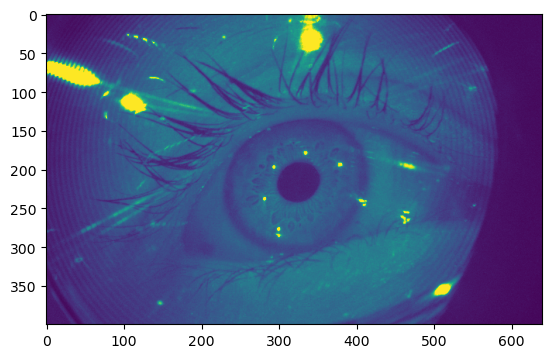

In [29]:
test_img = Image.open(
    "../../../../../../../../storage/ice1/shared/bmed6780/mip_group_4/"
    "openEDS Dataset/openEDS/openEDS/train/images/004645.png"
)
plt.imshow(test_img)

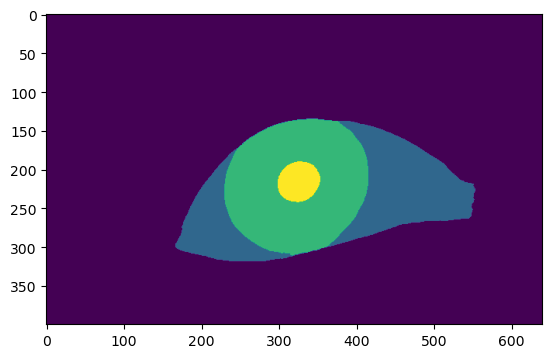

In [33]:
test_label = np.load(
    "../../../../../../../../storage/ice1/shared/bmed6780/mip_group_4/"
    "openEDS Dataset/openEDS/openEDS/train/labels/004645.npy"
)
plt.imshow(test_label)

In [39]:
!ls ../../autoROI_imgs
os.makedirs("../../autoROI_imgs/train", exist_ok=True)
os.makedirs("../../autoROI_imgs/train/images", exist_ok=True)
os.makedirs("../../autoROI_imgs/train/labels", exist_ok=True)
os.makedirs("../../autoROI_imgs/test", exist_ok=True)
os.makedirs("../../autoROI_imgs/test/images", exist_ok=True)
os.makedirs("../../autoROI_imgs/test/labels", exist_ok=True)
os.makedirs("../../autoROI_imgs/validation", exist_ok=True)
os.makedirs("../../autoROI_imgs/validation/images", exist_ok=True)
os.makedirs("../../autoROI_imgs/validation/labels", exist_ok=True)

cropped  cropped_masks	test  train  validation


In [40]:
images = []
labels = []

for subfolder in sorted(os.listdir("../../autoROI_imgs/cropped")):
    for image in sorted(os.listdir(f"../../autoROI_imgs/cropped/{subfolder}")):
        img = Image.open(f"../../autoROI_imgs/cropped/{subfolder}/{image}")
        images.append(img)
        label_name = image.split(".")[0]
        label = np.load(f"../../autoROI_imgs/cropped_masks/{subfolder}/{label_name}.npy")

print(len(images))
print(len(labels))

FileNotFoundError: [Errno 2] No such file or directory: '../../autoROI_imgs/cropped_masks/S_129/0.npy'

In [ ]:
# first—split off 20% as a temp‑set (for val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels,
    test_size=0.20,    # 20% will go into temp
    random_state=42,
    shuffle=True
)

# now split that temp into half/half → 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,    # half of the 20%
    random_state=42,
    shuffle=True
)

print(f"Train:      {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Test:       {len(X_test)} samples")

In [ ]:
def dump_split(X, Y, split):
    """
    X: list of PIL.Images
    Y: list of np.ndarrays
    split: 'train' or 'validation' or 'test'
    """
    img_out_dir = f"../../autoROI_imgs/{split}/images"
    msk_out_dir = f"../../autoROI_imgs/{split}/labels"

    for i, (img, msk) in enumerate(zip(X, Y)):
        # zero‑pad the index so they sort nicely on disk
        fname = f"{i:06d}"
        img.save(os.path.join(img_out_dir,  fname + ".png"))
        np.save(os.path.join(msk_out_dir,  fname + ".npy"), msk)

dump_split(X_train, y_train, "train")
dump_split(X_val,   y_val,   "validation")
dump_split(X_test,  y_test,  "test")